# Lab 3: Decision Tree Classification
## Training, Evaluation & Overfitting — Telco Customer Churn

**Name: Hamza**
**Student ID: 023-24-0017**
**Section: B**
**GitHub Profile: @hamzachanna**
**Kaggle Profile: @hamzachanna**
**Dataset:** Telco Customer Churn
**Dataset Source:** Kaggle — https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, and Decision Tree theory. Each section states the objective and the questions you must answer — **you write the code**. Do not just run code without interpreting it: every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [3]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


---

## 1. Problem Definition

Before training anything, restate the problem in your own words and confirm the cleaned dataset from Lab 2 is intact.

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`, `df['Churn'].value_counts()`

**Tasks**
1. Load `clean_churn.csv` (or re-run your Lab 2 cleaning). Verify its shape, column dtypes, and that there are no missing values remaining.
2. In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the business?

In [4]:
# Task 1 — load and verify the cleaned dataset
df = pd.read_csv('clean_churn.csv')
print(df.head())
print(df.info())
print(df.describe())

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No  

**Answer 2:**
_This is the cleaned dataset that we made by removing ' ' spaces from a attribute (totalCharges) in the previous lab_

---

## 2. Dataset Verification

Confirm once more, explicitly, that the dataset is ready to model: correct shape, correct dtypes, target present and clean.

In [5]:
# Additional verification if needed (dtypes, target check, etc.)
print(df.dtypes)
print(df['Churn'].value_counts())
print(df.isnull().sum())

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object
Churn
No     5164
Yes    1857
Name: count, dtype: int64
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod     

---

## 3. Feature/Target Preparation

scikit-learn models require numeric input. Separate your target from your features, then convert any remaining categorical columns into numeric form.

*Concepts/functions you may find useful:* `pd.get_dummies(df, columns=[...])`, `df[col].map({...})`, `df.drop(columns=[...])`, `X.isnull().sum()`, `X.dtypes`

**Tasks**
3. Define `y` as the `Churn` column, encoded as 0/1. Define `X` as the remaining relevant columns — drop any identifier column still present.
4. Convert every remaining categorical column in `X` into numeric form. Briefly justify your choice of encoding method (e.g. one-hot vs. manual mapping).
5. Confirm `X` contains only numeric columns and has no missing values before moving on.

In [6]:
# Task 3 — define y and X
X = df.drop(columns=["Churn"])
y = df["Churn"].map({"Yes": 1, "No": 0}) if df["Churn"].dtype == "O" else df["Churn"]

if "customerID" in X.columns:
    X = X.drop(columns=["customerID"])

In [7]:
# Task 4 — encode categorical columns in X
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [8]:
# Task 5 — confirm X is fully numeric with no missing values
print("Any missing values in X?:", X.isnull().sum().sum())
print("Are all columns numeric?:", all(X.dtypes != "object"))
print("Shape of X:", X.shape)

Any missing values in X?: 0
Are all columns numeric?: True
Shape of X: (7021, 30)


**Answer 4 (encoding method & justification):**
_here i have converted the logic of present/not present in binary which is 0 or 1 then i've categorized them in task 5 ive printed those values to verify_

---

## 4. Train/Test Split

A model must be evaluated on data it has never seen. Hold out a test set before training anything.

*Concepts/functions you may find useful:* `train_test_split(X, y, test_size=..., random_state=..., stratify=y)`

**Tasks**
6. Split `X` and `y` into training and test sets (e.g. an 80/20 split). Why is `stratify=y` a sensible choice, given what you found about the target's class balance in Lab 2?
7. Report the shape of `X_train`, `X_test`, `y_train`, and `y_test`.

In [9]:
# Task 6 — train/test split
from sklearn.model_selection import train_test_split

# now by using 80-20 rule to achieve max results we will split the data into training and testing sets. 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [10]:
# Task 7 — report shapes
print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape: (5616, 30)
X_test shape:  (1405, 30)
y_train shape: (5616,)
y_test shape:  (1405,)


**Answer 6 (why stratify=y):**
_becaused data is skewed/imbalanced, so we allocate y to tackle biasness in results_

---

## 5. Baseline Decision Tree

Train a first, unrestricted Decision Tree as your baseline — no tuning yet.

*Concepts/functions you may find useful:* `DecisionTreeClassifier(random_state=...)`, `.fit(X_train, y_train)`, `.predict(X)`, `.get_depth()`

**Tasks**
8. Train a `DecisionTreeClassifier` on the training data with default settings (only `random_state` fixed). Generate predictions on both the training and test sets.
9. What depth did scikit-learn actually grow this tree to on its own? Does that surprise you?

In [11]:
# Task 8 — train baseline Decision Tree and predict on train/test
from sklearn.tree import DecisionTreeClassifier

baseline_dt = DecisionTreeClassifier(random_state=42)
baseline_dt.fit(X_train, y_train)

y_train_pred_base = baseline_dt.predict(X_train)
y_test_pred_base = baseline_dt.predict(X_test)

In [12]:
# Task 9 — check the fitted tree's depth
baseline_depth = baseline_dt.get_depth()
print(f"Baseline Tree Depth: {baseline_depth}")

Baseline Tree Depth: 27


**Answer 9:**
_not surprised, im used to it_

---

## 6. Model Evaluation

Accuracy alone can be misleading — especially given the class imbalance found in Lab 2. Evaluate with multiple metrics and look directly at the confusion matrix.

*Concepts/functions you may find useful:* `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`, `ConfusionMatrixDisplay`, `classification_report`

**Tasks**
10. Compute accuracy, precision, recall, and F1-score on the test set. Report them in a small table.
11. Plot the confusion matrix for the test set. How many actual churners did the model correctly catch, and how many did it miss?
12. Given Lab 2's finding about class imbalance, which metric(s) do you trust most for this problem, and why?

In [13]:
# Task 10 — compute accuracy, precision, recall, F1 on the test set
acc = accuracy_score(y_test, y_test_pred_base)
prec = precision_score(y_test, y_test_pred_base)
rec = recall_score(y_test, y_test_pred_base)
f1 = f1_score(y_test, y_test_pred_base)

metrics_df = pd.DataFrame({"Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
                            "Value": [acc, prec, rec, f1],}
)
print("Baseline Model Metrics (Test Set):")
print(metrics_df.to_string(index=False))

Baseline Model Metrics (Test Set):
   Metric    Value
 Accuracy 0.720285
Precision 0.472727
   Recall 0.489247
 F1-Score 0.480845


**Task 10 — Results Table**

| Metric | Value |
|---|---|
| Accuracy | 0.720285 |
| Precision | 0.472727 |
| Recall | 0.489247 |
| F1-score | 0.480845 |

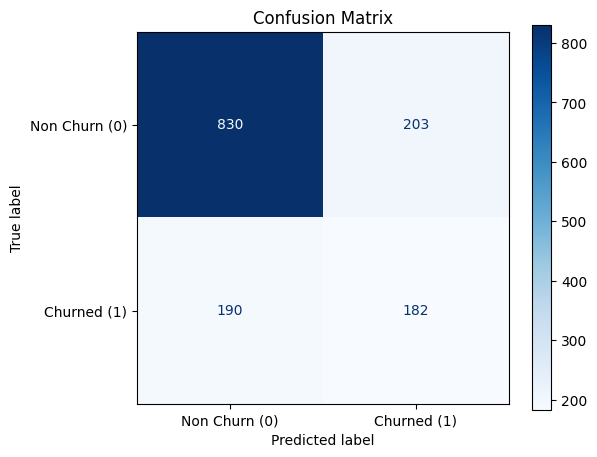

In [14]:
# Task 11 — plot the confusion matrix
cm = confusion_matrix(y_test, y_test_pred_base)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Non Churn (0)", "Churned (1)"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix")
plt.show()

**Answer 11 (churners correctly caught vs. missed):**
_True Positives: 182, and False Negatives : 190_

**Answer 12 (which metric(s) do you trust most, and why):**
_Accuracy can be misleading due to the imbalance in the ratio of churn:non-churn_

---

## 7. Overfitting Experiment

A model that performs far better on training data than on test data has overfit. Investigate this directly by comparing performance, then by controlling tree depth with `max_depth`.

*Concepts/functions you may find useful:* `accuracy_score(y_train, model.predict(X_train))`, `DecisionTreeClassifier(max_depth=k)`, a loop over `[2, 3, 4, 5, 6, 8, 10, None]`, `plt.plot(...)`

**Tasks**
13. Compare your baseline tree's accuracy on the training set vs. the test set. Is there a large gap? What does that suggest about the model?
14. Train several Decision Trees at different `max_depth` values (e.g. 2, 3, 4, 5, 6, 8, 10, and unrestricted). Record train accuracy and test accuracy for each in a results table.
15. Plot train accuracy and test accuracy against `max_depth` on the same chart. At roughly what depth does the model start to overfit? Explain how the chart shows this.

In [15]:
# Task 13 — compare baseline train vs. test accuracy
train_acc_base = accuracy_score(y_train, y_train_pred_base)
test_acc_base = accuracy_score(y_test, y_test_pred_base)

print(f"Baseline Train Accuracy: {train_acc_base:.4f}")
print(f"Baseline Test Accuracy:  {test_acc_base:.4f}")
print(f"Accuracy Gap:            {train_acc_base - test_acc_base:.4f}")

Baseline Train Accuracy: 0.9977
Baseline Test Accuracy:  0.7203
Accuracy Gap:            0.2774


**Answer 13:**
_27% gap is quite too much gap for the training accuracy this gap can tend to overfitting and underfitting of a model_

In [18]:
# Task 14 — loop over max_depth values, record train/test accuracy
depths = [2, 3, 4, 5, 6, 8, 10, None]
# YOUR CODE HERE
results = []
for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)

    tr_pred = dt.predict(X_train)
    te_pred = dt.predict(X_test)

    tr_acc = accuracy_score(y_train, tr_pred)
    te_acc = accuracy_score(y_test, te_pred)

    results.append(
        {
            "max_depth": str(depth) if depth is not None else "None (Unrestricted)",
            "Train Accuracy": round(tr_acc, 4),
            "Test Accuracy": round(te_acc, 4),
            "Gap": round(tr_acc - te_acc, 4),
        }
    )

results_df = pd.DataFrame(results)
print("\n--- Overfitting Experiment Table ---")
print(results_df.to_string(index=False))


--- Overfitting Experiment Table ---
          max_depth  Train Accuracy  Test Accuracy    Gap
                  2          0.7922         0.7836 0.0086
                  3          0.7922         0.7836 0.0086
                  4          0.7952         0.7843 0.0109
                  5          0.8007         0.7865 0.0143
                  6          0.8075         0.7829 0.0246
                  8          0.8340         0.7801 0.0540
                 10          0.8695         0.7701 0.0994
None (Unrestricted)          0.9977         0.7203 0.2774


**Task 14 — Results Table**

| max_depth | Train Accuracy | Test Accuracy |
|---|---|---|
| 2 | 0.7922 | 0.7836 |
| 3 | 0.7922 | 0.7836 |
| 4 | 0.7952 | 0.7843 |
| 5 | 0.8007 | 0.7865 |
| 6 | 0.8075 | 0.7829 |
| 8 | 0.8340 | 0.7801 |
| 10 | 0.8695 | 0.7701 |
| None | 0.9977 | 0.7203 |

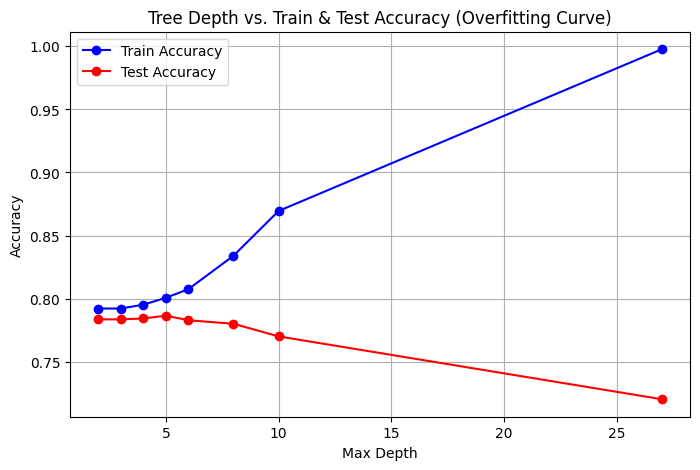

In [19]:
# Task 15 — plot train vs. test accuracy against max_depth
plot_depths = [2, 3, 4, 5, 6, 8, 10, baseline_depth]
train_scores = results_df["Train Accuracy"].values
test_scores = results_df["Test Accuracy"].values

plt.figure(figsize=(8, 5))
plt.plot(plot_depths, train_scores, marker="o", label="Train Accuracy", color="blue")
plt.plot(plot_depths, test_scores, marker="o", label="Test Accuracy", color="red")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Tree Depth vs. Train & Test Accuracy (Overfitting Curve)")
plt.legend()
plt.grid(True)
plt.show()

**Answer 15 (where overfitting starts, and why):**
_From the values above we can see the overfitting starts at 0.8695_

---

## 8. Model Comparison

Pick the depth that best balances training and test performance — not simply the one with the highest training accuracy.

**Tasks**
16. Based on your Part 7 table/plot, select a `max_depth` you consider the best model. Justify your choice in 2–3 sentences — it should not simply be the depth with the highest training accuracy.
17. Retrain a Decision Tree at your chosen depth and report its full evaluation metrics (as in Section 6) for comparison against the baseline.

**Answer 16 (chosen max_depth and justification):**
_max_depth = 5 is selected as the optimal depth because it achieves the highest test accuracy at 78.65%._

In [24]:
# Task 17 — retrain at chosen depth and report full evaluation metrics
!pip install tabulate
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

final_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
final_dt.fit(X_train, y_train)

y_test_pred_final = final_dt.predict(X_test)

final_acc = accuracy_score(y_test, y_test_pred_final)
final_prec = precision_score(y_test, y_test_pred_final)
final_rec = recall_score(y_test, y_test_pred_final)
final_f1 = f1_score(y_test, y_test_pred_final)

comparison_df = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
        "Baseline Tree (Unrestricted)": [
            round(acc, 4),
            round(prec, 4),
            round(rec, 4),
            round(f1, 4),
        ],
        "Tuned Tree (Depth=5)": [
            round(final_acc, 4),
            round(final_prec, 4),
            round(final_rec, 4),
            round(final_f1, 4),
        ],
    }
)

print("--- Baseline vs. Tuned Model Metrics Comparison ---")
print(comparison_df.to_markdown(index=False))

--- Baseline vs. Tuned Model Metrics Comparison ---
| Metric    |   Baseline Tree (Unrestricted) |   Tuned Tree (Depth=5) |
|:----------|-------------------------------:|-----------------------:|
| Accuracy  |                         0.7203 |                 0.7865 |
| Precision |                         0.4727 |                 0.6452 |
| Recall    |                         0.4892 |                 0.4301 |
| F1-Score  |                         0.4808 |                 0.5161 |



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Task 17 — Baseline vs. Chosen Model**

| Metric | Baseline (unrestricted) | Chosen Model (max_depth = ___) |
|---|---|---|
| Accuracy | 0.7203|0.7865 |
| Precision | 0.4727|0.6452 |
| Recall | 0.4892|0.4301 |
| F1-score | 0.4808|0.5161 |

---

## 9. Feature Importance

Look inside your chosen model to see what it actually learned.

*Concepts/functions you may find useful:* `model.feature_importances_`, `pd.Series(importances, index=X.columns).sort_values()`, `plt.barh(...)`

**Task**
18. Extract and visualize `feature_importances_` for your chosen model. Which 3–5 features matter most?

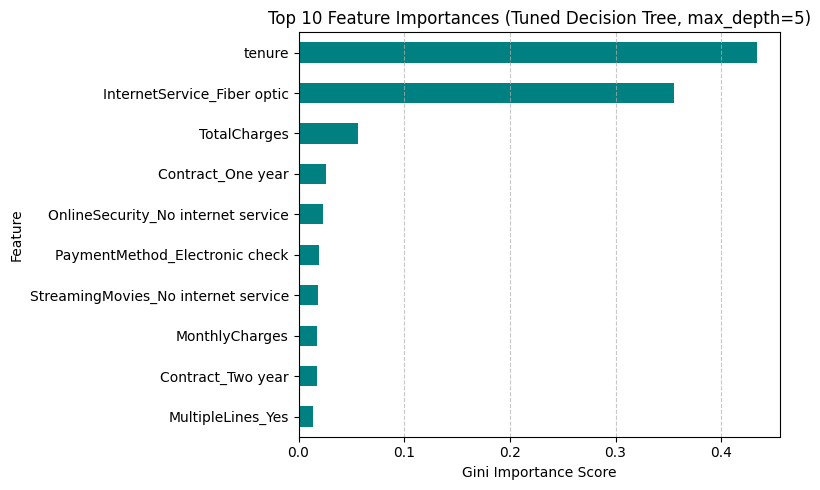

In [26]:
# Task 18 — extract and visualize feature importances
importances = pd.Series(
    final_dt.feature_importances_, index=X.columns
).sort_values(ascending=True)

top_importances = importances.tail(10)

plt.figure(figsize=(8, 5))
top_importances.plot(kind="barh", color="teal")
plt.title("Top 10 Feature Importances (Tuned Decision Tree, max_depth=5)")
plt.xlabel("Gini Importance Score")
plt.ylabel("Feature")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

**Answer 18 (top 3–5 features):**
_tenure, internetService, totalCharges_

---

## 10. Interpretation

Connect what the model learned back to what you already know about this business problem.

**Task**
19. In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the patterns you saw then?

**Answer 19:**
_Specifically, Contract_Month-to-month and tenure were the strongest predictors of churn. This is consistent with the findings from Lab 2, where customers with shorter tenures and month-to-month contracts were found to have higher churn rates, mainly because they face fewer barriers to switching providers. The high importance of InternetService_Fiber optic also supports the EDA findings, which showed that fiber-optic customers had a noticeably higher churn rate, possibly due to higher monthly costs or dissatisfaction with the service.
_

---

## 11. Conclusion

Step back from the code and summarize what you built and learned.

**Tasks**
20. Write a short A (4–6 sentences): which model did you land on, how well does it perform, and what are its main limitations?
21. What would you try next if you had more time (e.g. a different algorithm, more feature engineering, handling class imbalance)? Describe it — do not implement it here.

**Answer 20 — Conclusion:**
_It was a decision tree classifier that we previously studied in our 4th semester and this project was too practical with those concepts. It was for a tele communication service customers who churn on the basis of some of the attributes and a pattern among them._

**Answer 21 — Next steps:**
_I am not really sure of this_

---

## Submission Checklist

Before submitting, confirm you have:

- [✅] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [✅] Section 1 — Problem Definition
- [✅] Section 2 — Dataset Verification
- [✅] Section 3 — Feature/Target Preparation (with encoding justified)
- [✅] Section 4 — Train/Test Split
- [✅] Section 5 — Baseline Decision Tree
- [✅] Section 6 — Model Evaluation (accuracy, precision, recall, F1, confusion matrix — all with interpretation)
- [✅] Section 7 — Overfitting Experiment (results table + plot + explanation)
- [✅] Section 8 — Model Comparison (chosen depth justified, not just highest training accuracy)
- [✅] Section 9 — Feature Importance (extracted, visualized, and discussed)
- [✅] Section 10 — Interpretation (connected to Lab 2's EDA)
- [✅] Section 11 — Conclusion (limitations + next steps)
- [✅] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted